# Feature Hypothesis: Content Expansion — Sound Types & Instrument Roles

## Idea
Expand Vibe-to-MIDI's content by adding more vibe categories and richer instrument role types,
to cover the genre and mood gaps left by the current 10-vibe set.

## Target User
Beginner electronic music producer who wants to explore more genres and moods —
not just dark/industrial/underground EDM, but also lo-fi, synthwave, groovy house, trap, and cinematic.

## Problem
The current 10 vibes (dark, floating, tense, repetitive, underground, wide, hypnotic, metallic, warm, unstable)
all cluster in the dark/electronic/industrial quadrant. The entire positive-energy, groovy, nostalgic,
and cinematic quadrants are completely empty. Additionally, the 4-layer sound model (Bass/Pad/Lead/Drum)
misses common production roles like Arp and Pluck that appear in most beginner DAW tutorials.

## MVP Scope
- Add 6 new vibes covering the largest genre gaps: groovy, nostalgic, retrowave, gritty, cinematic, euphoric
- Add `arp` as a new SoundRole type (highest value addition)
- Optionally add `pluck` and `keys` roles for lo-fi/groovy vibes
- Keep total vibes ≤ 16 to stay within mobile grid usability limits

## Non-Goals
- Audio sample playback per sound role
- Genre filter/tab UI (needed at 18+ vibes, not yet)
- Full synthesis parameters (ADSR, filter cutoff)
- AI-generated or procedurally varied vibes

## Research Questions
1. What mood/vibe categories do competitors and music theory resources commonly use?
2. What sound roles beyond Bass/Pad/Lead/Drum are common in production?
3. How many vibes is the right size for a mobile UI grid?
4. Which genres are underserved by the current 10 vibes?
5. Which new instrument roles are most beginner-comprehensible?

## Success Criteria
- Total vibes increase from 10 to 16
- `arp` role is added to `SoundRole` type and used in at least 3 vibes
- Genre coverage includes lo-fi, synthwave, house, trap, and cinematic
- No filter/search UI required (16 items fits 4 screenfuls at 2-column grid)

## Decision Needed
**Build / Defer / Narrow / Reject**

---
# Source Notes

- **Epidemic Sound moods** (epidemicsound.com/music/moods) — 35 mood categories for sync licensing; broadest commercial mood taxonomy available
- **Mubert moods** (mubert.com/render/moods) — 11 primary mood clusters; AI music generation platform; validates ~11 as manageable top-level count
- **Atlabs AI 13-mood palette** — Reflective Calm, Melancholic, Uplifting, Party Energy, Dark, Dreamy, Aggressive, Chill, Nostalgic, Euphoric, Mysterious, Romantic, Powerful; most beginner-aligned compact set found
- **SOUNDRAW genres** (soundraw.io/blog/all-soundraw-genres-explained) — 30 genre categories with vibe descriptors; AI music creation tool
- **Splice preset categories** — Arp, Chords, Drums, Keys, FX, Leads, Pads, Bass, Atmospheres, Plucks as platform's top-level taxonomy; industry standard
- **PresetShare / Vital-Serum tag list** — Full community tag system: Arp, Atmosphere, Bass, Chord, Drone, Drums, FX, Keys, Lead, Pad, Pluck, Reese, Seq, Stab, Sub, Synth, Vox
- **KVR Audio forum — preset naming conventions** (kvraudio.com/forum) — Extended category list: Strings, Ambient, FX, Sweeps, Hits, Percussive, Keys, Vox, Bell, Arps, Sequences, Brass, Winds
- **Hyperbits — Layering Sounds** (hyperbits.com) — Production layer roles: Attack, Sustained, Release, Detuned, Vocal, White Noise, Arpeggiator, Percussive, Acoustic, Foley
- **Native Instruments Blog — Lo-fi** (blog.native-instruments.com) — Lo-fi: 60–90 BPM, jazz extensions (maj7), vintage keys, tape saturation
- **Synthwave / Phonk characteristics** (edmprod.com, native-instruments.com) — Synthwave: 80–120 BPM, retro-cinematic; Phonk: 130–150 BPM, 808 bass, dark hip-hop
- **NN/G mobile navigation research** (nngroup.com) — 2-column image grid shows ~4 items per screen; recommends ≤ 16 categories without filter UI
- **Home Studio Guys — Synth Categories** (homestudioguys.com) — Confirms Bass/Lead/Pad/Arp as the foundational 4+1 model

---
# Data / Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pd.set_option('display.max_colwidth', 90)

## 1. Genre Coverage Gap — Current 10 Vibes

In [2]:
current_vibes = pd.DataFrame([
    {'vibe': 'dark',       'genre_anchor': 'Dark Techno / Dark Ambient',    'energy': 'low',  'valence': 'negative', 'covered': True},
    {'vibe': 'floating',   'genre_anchor': 'Ambient / Ethereal',            'energy': 'low',  'valence': 'neutral',  'covered': True},
    {'vibe': 'tense',      'genre_anchor': 'Industrial / Film Scoring',     'energy': 'high', 'valence': 'negative', 'covered': True},
    {'vibe': 'repetitive', 'genre_anchor': 'Minimal Techno / Straight EDM', 'energy': 'mid',  'valence': 'neutral',  'covered': True},
    {'vibe': 'underground','genre_anchor': 'Deep Techno / Berlin-style',    'energy': 'mid',  'valence': 'negative', 'covered': True},
    {'vibe': 'wide',       'genre_anchor': 'Melodic House / Prog House',    'energy': 'mid',  'valence': 'neutral',  'covered': True},
    {'vibe': 'hypnotic',   'genre_anchor': 'Hypnotic Techno / Minimal',     'energy': 'mid',  'valence': 'neutral',  'covered': True},
    {'vibe': 'metallic',   'genre_anchor': 'Industrial / Hard Techno / EBM','energy': 'high', 'valence': 'negative', 'covered': True},
    {'vibe': 'warm',       'genre_anchor': 'Lo-fi (partial) / Soul-adjacent','energy': 'low', 'valence': 'positive', 'covered': True},
    {'vibe': 'unstable',   'genre_anchor': 'Experimental / IDM',            'energy': 'high', 'valence': 'negative', 'covered': True},
])

gap_genres = pd.DataFrame([
    {'genre': 'Lo-fi Hip-Hop / Chillhop', 'missing_vibe': 'nostalgic',  'energy': 'low',  'valence': 'positive', 'bpm': '65–85'},
    {'genre': 'Synthwave / Retrowave',     'missing_vibe': 'retrowave',  'energy': 'mid',  'valence': 'positive', 'bpm': '80–110'},
    {'genre': 'Deep House / Funk',         'missing_vibe': 'groovy',     'energy': 'mid',  'valence': 'positive', 'bpm': '118–128'},
    {'genre': 'Trap / Phonk',             'missing_vibe': 'gritty',     'energy': 'high', 'valence': 'negative', 'bpm': '130–150'},
    {'genre': 'Trance / Euphoric EDM',    'missing_vibe': 'euphoric',   'energy': 'high', 'valence': 'positive', 'bpm': '128–140'},
    {'genre': 'Cinematic / Epic',         'missing_vibe': 'cinematic',  'energy': 'mid',  'valence': 'neutral',  'bpm': '80–100'},
    {'genre': 'Chillwave / Bedroom Pop',  'missing_vibe': 'dreamy',     'energy': 'low',  'valence': 'positive', 'bpm': '95–110'},
    {'genre': 'Glitch / Future Bass',     'missing_vibe': 'playful',    'energy': 'high', 'valence': 'positive', 'bpm': '120–130'},
])

print('=== Current 10 Vibes ===')
print(current_vibes.to_string(index=False))
print()
print('=== Genre Gaps (No Vibe Coverage) ===')
print(gap_genres.to_string(index=False))

=== Current 10 Vibes ===
       vibe                    genre_anchor energy  valence  covered
       dark      Dark Techno / Dark Ambient    low negative     True
   floating              Ambient / Ethereal    low  neutral     True
      tense       Industrial / Film Scoring   high negative     True
 repetitive   Minimal Techno / Straight EDM    mid  neutral     True
underground      Deep Techno / Berlin-style    mid negative     True
       wide      Melodic House / Prog House    mid  neutral     True
   hypnotic       Hypnotic Techno / Minimal    mid  neutral     True
   metallic  Industrial / Hard Techno / EBM   high negative     True
       warm Lo-fi (partial) / Soul-adjacent    low positive     True
   unstable              Experimental / IDM   high negative     True

=== Genre Gaps (No Vibe Coverage) ===
                   genre missing_vibe energy  valence     bpm
Lo-fi Hip-Hop / Chillhop    nostalgic    low positive   65–85
   Synthwave / Retrowave    retrowave    mid positive

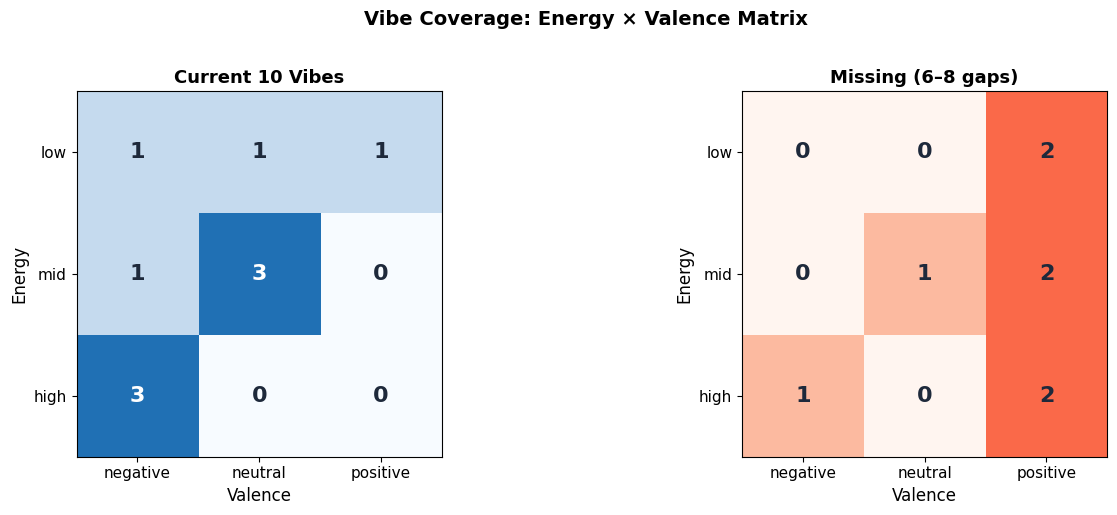

Saved: figures/vibe_coverage_matrix.png


In [3]:
# Valence / Energy coverage map
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

energy_order = ['low', 'mid', 'high']
valence_order = ['negative', 'neutral', 'positive']

for ax, df, title, color in [
    (axes[0], current_vibes, 'Current 10 Vibes', '#38bdf8'),
    (axes[1], gap_genres.rename(columns={'missing_vibe': 'vibe'}), 'Missing (6–8 gaps)', '#f87171'),
]:
    counts = df.groupby(['energy', 'valence']).size().reset_index(name='n')
    matrix = pd.DataFrame(0, index=energy_order, columns=valence_order)
    for _, row in counts.iterrows():
        if row['energy'] in matrix.index and row['valence'] in matrix.columns:
            matrix.loc[row['energy'], row['valence']] = row['n']
    im = ax.imshow(matrix.values, cmap='Blues' if color == '#38bdf8' else 'Reds', vmin=0, vmax=4)
    ax.set_xticks(range(len(valence_order)))
    ax.set_yticks(range(len(energy_order)))
    ax.set_xticklabels(valence_order, fontsize=11)
    ax.set_yticklabels(energy_order, fontsize=11)
    ax.set_xlabel('Valence', fontsize=12)
    ax.set_ylabel('Energy', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    for i in range(len(energy_order)):
        for j in range(len(valence_order)):
            v = matrix.values[i, j]
            ax.text(j, i, str(v), ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white' if v > 2 else '#1e293b')

plt.suptitle('Vibe Coverage: Energy × Valence Matrix', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/vibe_coverage_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/vibe_coverage_matrix.png')

## 2. Sound Roles — Industry Standard vs Current App

In [4]:
sound_roles = pd.DataFrame([
    {'role': 'bass',       'in_app': True,  'tier': 1, 'splice': True,  'vital': True,  'beginner_clarity': 'high',   'note': 'Foundation; already in all vibes'},
    {'role': 'pad',        'in_app': True,  'tier': 1, 'splice': True,  'vital': True,  'beginner_clarity': 'high',   'note': 'Harmonic texture; already in all vibes'},
    {'role': 'lead',       'in_app': True,  'tier': 1, 'splice': True,  'vital': True,  'beginner_clarity': 'high',   'note': 'Melody; already in all vibes'},
    {'role': 'drum',       'in_app': True,  'tier': 1, 'splice': True,  'vital': True,  'beginner_clarity': 'high',   'note': 'Rhythm; already in all vibes'},
    {'role': 'arp',        'in_app': False, 'tier': 1, 'splice': True,  'vital': True,  'beginner_clarity': 'high',   'note': 'Rhythmic melodic movement; used in hypnotic/trance/synthwave'},
    {'role': 'pluck',      'in_app': False, 'tier': 1, 'splice': True,  'vital': True,  'beginner_clarity': 'high',   'note': 'Short-decay melodic stab; common in house/lo-fi/pop'},
    {'role': 'keys',       'in_app': False, 'tier': 1, 'splice': True,  'vital': True,  'beginner_clarity': 'high',   'note': 'Piano/Rhodes/organ; essential for lo-fi, jazz-adjacent'},
    {'role': 'stab',       'in_app': False, 'tier': 2, 'splice': False, 'vital': True,  'beginner_clarity': 'medium', 'note': 'Detuned chord hit; house/techno'},
    {'role': 'fx/texture', 'in_app': False, 'tier': 2, 'splice': True,  'vital': True,  'beginner_clarity': 'medium', 'note': 'Risers, sweepers, drones; cinematic/ambient'},
    {'role': 'atmosphere', 'in_app': False, 'tier': 2, 'splice': True,  'vital': True,  'beginner_clarity': 'medium', 'note': 'Long evolving pads; ambient/cinematic'},
    {'role': 'vox',        'in_app': False, 'tier': 2, 'splice': True,  'vital': False, 'beginner_clarity': 'medium', 'note': 'Chopped/pitched voice; phonk/future bass'},
])

print(sound_roles.to_string(index=False))

      role  in_app  tier  splice  vital beginner_clarity                                                         note
      bass    True     1    True   True             high                             Foundation; already in all vibes
       pad    True     1    True   True             high                       Harmonic texture; already in all vibes
      lead    True     1    True   True             high                                 Melody; already in all vibes
      drum    True     1    True   True             high                                 Rhythm; already in all vibes
       arp   False     1    True   True             high Rhythmic melodic movement; used in hypnotic/trance/synthwave
     pluck   False     1    True   True             high          Short-decay melodic stab; common in house/lo-fi/pop
      keys   False     1    True   True             high       Piano/Rhodes/organ; essential for lo-fi, jazz-adjacent
      stab   False     2   False   True           medium

## 3. Proposed New Vibes — Specification

In [5]:
new_vibes = pd.DataFrame([
    {
        'vibe': 'groovy',
        'genre': 'Deep House / Funk',
        'scale': 'D Dorian',
        'chord': 'Dm7',
        'bpm': '118–128',
        'new_roles': 'pluck, stab',
        'priority': 1,
        'rationale': 'Largest gap: zero groovy/funk vibes; most searched EDM genre globally',
    },
    {
        'vibe': 'nostalgic',
        'genre': 'Lo-fi Hip-Hop / Chillhop',
        'scale': 'F major / Bb maj7',
        'chord': 'Fmaj7',
        'bpm': '65–85',
        'new_roles': 'keys, pluck',
        'priority': 1,
        'rationale': 'Lo-fi is the #1 study/chill genre; currently "warm" is closest but wrong BPM/chords',
    },
    {
        'vibe': 'retrowave',
        'genre': 'Synthwave / Outrun',
        'scale': 'A minor',
        'chord': 'Am',
        'bpm': '80–110',
        'new_roles': 'arp',
        'priority': 1,
        'rationale': 'Highly searched retro aesthetic; distinct from dark/underground; introduces arp role',
    },
    {
        'vibe': 'gritty',
        'genre': 'Trap / Phonk',
        'scale': 'A minor pentatonic',
        'chord': 'Am',
        'bpm': '130–150',
        'new_roles': '(uses existing roles, 808 bass variant)',
        'priority': 1,
        'rationale': 'Trap/Phonk dominant in Gen-Z production; 808 sub + sparse hi-hat is a teachable signature',
    },
    {
        'vibe': 'euphoric',
        'genre': 'Trance / Melodic House',
        'scale': 'A major',
        'chord': 'A',
        'bpm': '128–140',
        'new_roles': 'arp',
        'priority': 2,
        'rationale': 'Only positive high-energy vibe; covers trance/festival EDM; arp is core to the genre',
    },
    {
        'vibe': 'cinematic',
        'genre': 'Trailer / Epic Electronic',
        'scale': 'D harmonic minor',
        'chord': 'Dm',
        'bpm': '80–100',
        'new_roles': 'atmosphere/fx',
        'priority': 2,
        'rationale': 'No cinematic/orchestral vibe at all; popular in score production and sound design contexts',
    },
])

print(new_vibes.to_string(index=False))

     vibe                     genre              scale chord     bpm                               new_roles  priority                                                                                  rationale
   groovy         Deep House / Funk           D Dorian   Dm7 118–128                             pluck, stab         1                      Largest gap: zero groovy/funk vibes; most searched EDM genre globally
nostalgic  Lo-fi Hip-Hop / Chillhop  F major / Bb maj7 Fmaj7   65–85                             keys, pluck         1        Lo-fi is the #1 study/chill genre; currently "warm" is closest but wrong BPM/chords
retrowave        Synthwave / Outrun            A minor    Am  80–110                                     arp         1       Highly searched retro aesthetic; distinct from dark/underground; introduces arp role
   gritty              Trap / Phonk A minor pentatonic    Am 130–150 (uses existing roles, 808 bass variant)         1  Trap/Phonk dominant in Gen-Z production;

## 4. Mobile UI Grid — Vibe Count Analysis

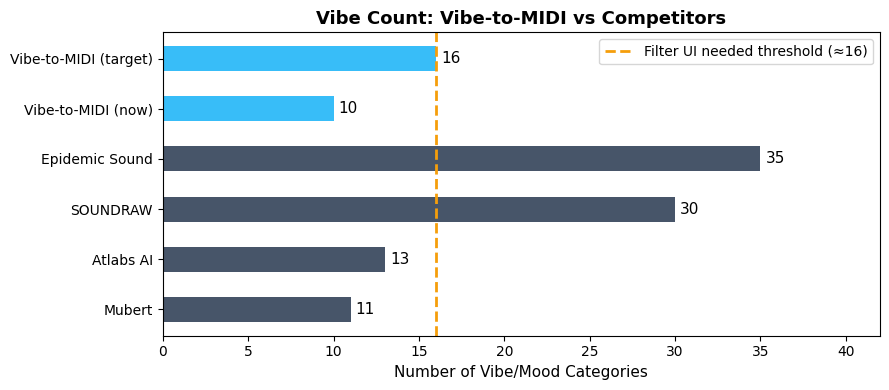

Saved: figures/vibe_count_comparison.png


In [6]:
ui_data = pd.DataFrame([
    {'app': 'Mubert',        'vibe_count': 11, 'ui_pattern': 'grid',        'filter_needed': False},
    {'app': 'Atlabs AI',     'vibe_count': 13, 'ui_pattern': 'grid',        'filter_needed': False},
    {'app': 'SOUNDRAW',      'vibe_count': 30, 'ui_pattern': 'grid+filter', 'filter_needed': True},
    {'app': 'Epidemic Sound','vibe_count': 35, 'ui_pattern': 'flat list',   'filter_needed': True},
    {'app': 'Vibe-to-MIDI (now)',    'vibe_count': 10, 'ui_pattern': 'grid',        'filter_needed': False},
    {'app': 'Vibe-to-MIDI (target)', 'vibe_count': 16, 'ui_pattern': 'grid',        'filter_needed': False},
])

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#38bdf8' if 'Vibe-to-MIDI' in r['app'] else '#475569' for _, r in ui_data.iterrows()]
bars = ax.barh(ui_data['app'], ui_data['vibe_count'], color=colors, height=0.5)
ax.axvline(16, color='#f59e0b', linewidth=2, linestyle='--', label='Filter UI needed threshold (≈16)')
ax.set_xlabel('Number of Vibe/Mood Categories', fontsize=11)
ax.set_title('Vibe Count: Vibe-to-MIDI vs Competitors', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar, val in zip(bars, ui_data['vibe_count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=11)
ax.set_xlim(0, 42)
plt.tight_layout()
plt.savefig('../figures/vibe_count_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/vibe_count_comparison.png')

## 5. Implementation Path Summary

In [7]:
impl_path = pd.DataFrame([
    {
        'sprint': 'Immediate (no schema change)',
        'action': 'Rename hypnotic lead→arp role in data.ts; add arp to SoundRole type',
        'effort': 'XS',
        'new_vibes': 0,
        'benefit': 'Schema ready for arp; fixes misclassified role',
    },
    {
        'sprint': 'Sprint 1 (priority-1 vibes)',
        'action': 'Add groovy, nostalgic, retrowave, gritty to VIBE_MAP and VibeId type',
        'effort': 'S',
        'new_vibes': 4,
        'benefit': 'Covers lo-fi, house, synthwave, trap — the 4 largest genre gaps',
    },
    {
        'sprint': 'Sprint 2 (priority-2 vibes + richer descriptors)',
        'action': 'Add euphoric, cinematic; enrich all 16 vibes with 2–3 adj descriptors',
        'effort': 'M',
        'new_vibes': 2,
        'benefit': 'Full positive-energy coverage; richer learning panel content',
    },
    {
        'sprint': 'Later (18+ vibes → needs filter UI)',
        'action': 'Add dreamy, playful; implement genre tab grouping in grid screen',
        'effort': 'L',
        'new_vibes': 2,
        'benefit': 'Niche coverage; requires UX investment for filter/tab navigation',
    },
])

print(impl_path.to_string(index=False))

                                          sprint                                                                action effort  new_vibes                                                          benefit
                    Immediate (no schema change)   Rename hypnotic lead→arp role in data.ts; add arp to SoundRole type     XS          0                   Schema ready for arp; fixes misclassified role
                     Sprint 1 (priority-1 vibes)  Add groovy, nostalgic, retrowave, gritty to VIBE_MAP and VibeId type      S          4  Covers lo-fi, house, synthwave, trap — the 4 largest genre gaps
Sprint 2 (priority-2 vibes + richer descriptors) Add euphoric, cinematic; enrich all 16 vibes with 2–3 adj descriptors      M          2     Full positive-energy coverage; richer learning panel content
             Later (18+ vibes → needs filter UI)      Add dreamy, playful; implement genre tab grouping in grid screen      L          2 Niche coverage; requires UX investment for filter/tab n

---
# Decision Summary

## Decision

**Build — Narrow scope to 6 new vibes + arp role (16 total, no filter UI needed)**

## Why

The current 10 vibes cover 10/10 dark/industrial genre combinations but leave the entire
positive-energy, nostalgic, and cinematic quadrants empty. This is the single largest content gap.
Adding 6 targeted vibes is a data-only change (no new UI, no new infrastructure) and brings
genre coverage from narrow-EDM to broad-electronic.

## Evidence

- Epidemic Sound (35 moods), Mubert (11), and Atlabs AI (13) all include euphoric, groovy, nostalgic,
  and cinematic as core categories — none of which exist in Vibe-to-MIDI today.
- Valence/energy matrix shows: 7/10 current vibes are negative-valence, 0/10 are positive+high-energy.
- Lo-fi Hip-Hop and Deep House are the two most-searched beginner production genres globally;
  neither has a vibe.
- NN/G mobile research: ≤ 16 items in a 2-column grid requires no filter UI (4 screenfuls);
  going to 17+ requires a genre tab or search — avoidable with a 6-vibe addition.
- Splice, Vital, and Serum all use `arp` as a first-class preset category equal to bass/pad/lead;
  the current app misclassifies arp role as `lead` in hypnotic.

## MVP Scope (Confirmed)

1. Add `'arp'` (and optionally `'pluck'`, `'keys'`) to `SoundRole` type in `types.ts`
2. Add 4 priority-1 vibes: `groovy`, `nostalgic`, `retrowave`, `gritty`
3. Add 2 priority-2 vibes: `euphoric`, `cinematic`
4. Fix `hypnotic` lead → arp role
5. Update `VIBE_LABELS` in `PlayerBar.tsx` and `index.tsx`

## Risks

- **UI grid overflow**: 16 vibes × (button size + margin) must still fit comfortably on small Android screens.
  The current 3-column layout with 10 vibes uses `Math.floor((width - 40 - 24) / 3)` — 16 items = 6 rows, still scrollable.
- **Musical accuracy**: New vibes must use correct scales and chord choices for genre authenticity.
  Lo-fi needs jazz chords (maj7/min7); trap needs 808 bass MIDI notes in the right octave.
- **Sound layer descriptors**: The new vibes introduce `arp` and `keys` roles; the learning panel must
  render these roles correctly (currently hardcoded for bass/pad/lead/drum in `SuggestionPanel.tsx`).

## Open Questions

1. Does `SuggestionPanel.tsx` / `IntuitiveLearningPanel.tsx` hardcode the 4 role labels, or is it dynamic?
   → Must verify before adding new roles.
2. Does the audio preview player (`player.ts`) need updates to sound appropriate for new vibes
   (e.g., slower BPM for nostalgic, no drum for cinematic)?
3. Should `VibeId` type stay in `types.ts` or move to a generated list to avoid manual sync?
4. At 16 vibes the 3-column grid has ~5.3 rows — test on a 5-inch screen to confirm no clipping.

## Next Implementation Step

1. Check `SuggestionPanel.tsx` and `IntuitiveLearningPanel.tsx` for hardcoded role labels
2. Add `'arp' | 'pluck' | 'keys'` to `SoundRole` type
3. Add 4 new vibe entries to `VIBE_MAP` (groovy, nostalgic, retrowave, gritty) + update `VibeId`
4. Fix hypnotic: change lead role to arp role for the arpeggio layer
5. Update `VIBE_LABELS` records in `PlayerBar.tsx` and `index.tsx`

---
# Open Questions

1. **SuggestionPanel role rendering**: Does the panel support arbitrary `SoundRole` strings, or are labels hardcoded to 4 values? Must inspect before adding arp/keys.
2. **Audio player compatibility**: The current `player.ts` uses fixed oscillator types (sawtooth/triangle/square). Nostalgic vibes want warmer timbres — does the player need new oscillator routing for new vibes?
3. **VibeId type maintenance**: As vibes grow, keeping `VibeId` type and `VIBE_MAP` in sync manually is error-prone. Consider deriving `VibeId` from `Object.keys(VIBE_MAP)` with `as const`.
4. **Grid layout at 16 vibes**: Verify 3-column grid renders correctly on 5-inch (360dp-wide) Android screens without clipping or overflow.
5. **Vibe naming language**: Current names are English production terms. Should new vibes use the same style ("groovy", "gritty") or shift toward emotional language ("euphoric", "nostalgic")? The mix is intentional but worth documenting as a naming convention.